                       **Milestone 3: Geospatial Disaster Analysis**

The objective of this milestone is to analyze and visualize the geographical distribution of natural disaster declarations across the United States. In this stage, the cleaned dataset is used to identify patterns in disaster occurrences across different states and regions.

In [ ]:
!pip install geopandas

In [ ]:
!pip install folium

In [8]:
# Data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Geospatial libraries
import geopandas as gpd
import folium

Pandas → for reading and manipulating dataset

NumPy → numerical operations

Matplotlib / Seaborn → static charts

Plotly → interactive maps

GeoPandas → geographical data handling

Folium → interactive geographic maps

In [10]:
# Load cleaned dataset
data = pd.read_csv("usnd_cleaned.csv")

# Display first few rows
data.head()

,state,incidentType,declarationDate,year,month
0,OR,Fire,2024-08-09 00:00:00+00:00,2024,8
1,OR,Fire,2024-08-06 00:00:00+00:00,2024,8
2,OR,Fire,2024-08-02 00:00:00+00:00,2024,8
3,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017,5
4,AL,Severe Storm,2016-01-21 00:00:00+00:00,2016,1


In [11]:
# Check dataset structure
data.info()

# Check missing values
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69634 entries, 0 to 69633
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   state            69634 non-null  object
 1   incidentType     69634 non-null  object
 2   declarationDate  69634 non-null  object
 3   year             69634 non-null  int64 
 4   month            69634 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 2.7+ MB


state              0
incidentType       0
declarationDate    0
year               0
month              0
dtype: int64

Explanation

This step ensures:

Dataset is correctly loaded

Required columns exist

No missing values in important columns

Required columns should include:

state

incidentType

year

month

In [12]:
# Unique states present in dataset
data['state'].unique()

# Count number of states
print("Total states in dataset:", data['state'].nunique())

Total states in dataset: 59


In [13]:
# Count disasters per state
state_disaster_counts = data['state'].value_counts().reset_index()

# Rename columns for clarity
state_disaster_counts.columns = ['state', 'disaster_count']

# Display results
state_disaster_counts.head()

,state,disaster_count
0,TX,5388
1,KY,3355
2,MO,2830
3,FL,2791
4,GA,2765


**Visualization 1 Choropleth Map (Disaster Frequency)**

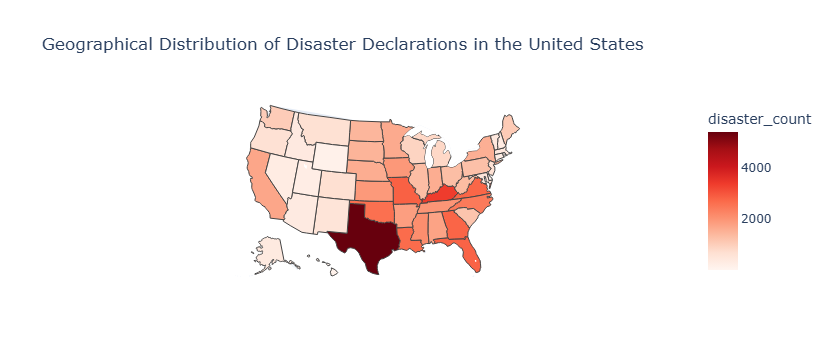

In [14]:
# Create choropleth map using Plotly

fig = px.choropleth(
    state_disaster_counts,
    locations='state',              # state column
    locationmode="USA-states",      # map uses US state codes
    color='disaster_count',         # color intensity
    scope="usa",                    # focus on USA
    color_continuous_scale="Reds",
    title="Geographical Distribution of Disaster Declarations in the United States"
)

fig.show()

**Interpretation** 

The choropleth map illustrates the geographical distribution of disaster declarations across the United States. States with darker shades represent a higher frequency of disaster declarations. From the visualization, southern states such as Texas and Florida tend to experience a greater number of disasters compared to many northern states. This pattern may be influenced by the higher exposure of southern coastal regions to hurricanes, tropical storms, and flooding events.

**Visualization 2 Top 10 Disaster-Prone States**

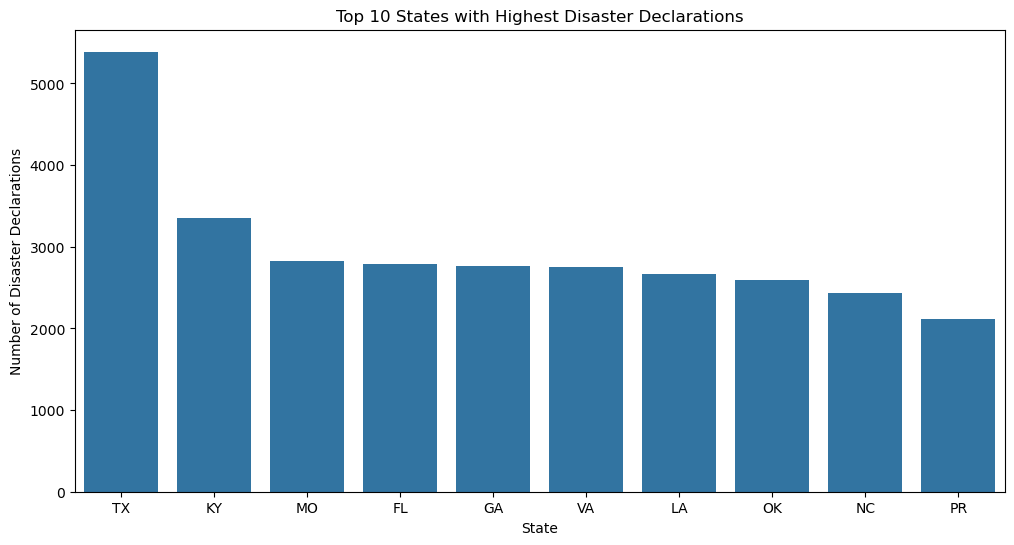

In [16]:
# Select top 10 states
top_states = state_disaster_counts.head(10)

# Plot bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_states,
    x='state',
    y='disaster_count'
)

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disaster Declarations")

plt.show()

**Interpretation**

This bar chart compares the number of disaster declarations among the top ten most affected states. The visualization clearly highlights states that experience disasters more frequently. These states often face environmental conditions such as coastal storms, wildfires, flooding, and severe weather patterns. The analysis helps identify disaster-prone regions that may require stronger disaster preparedness and management strategies.

In [17]:
# Group by state and incident type
state_incident = data.groupby(['state','incidentType']).size().reset_index(name='count')

# Display first few rows
state_incident.head()

,state,incidentType,count
0,AK,Biological,121
1,AK,Coastal Storm,2
2,AK,Earthquake,13
3,AK,Fire,35
4,AK,Flood,71


**Visualization 3 Stacked Bar Chart (Incident Types per State)**

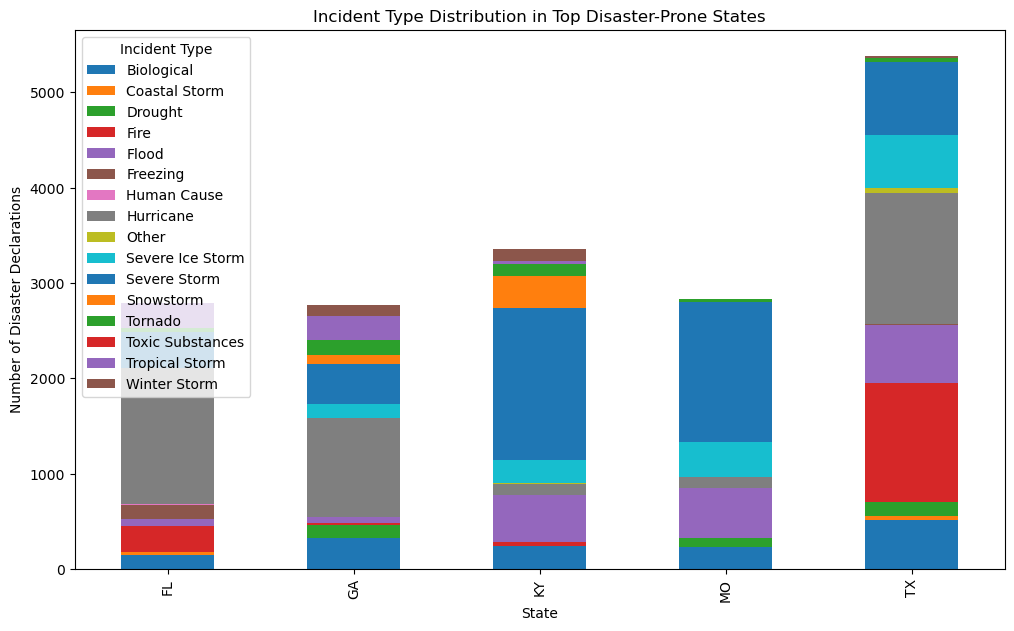

In [18]:
# Get top 5 states
top5_states = state_disaster_counts.head(5)['state']

# Filter dataset
filtered_data = state_incident[state_incident['state'].isin(top5_states)]

# Create stacked bar chart
pivot_data = filtered_data.pivot(index='state', columns='incidentType', values='count')

pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title("Incident Type Distribution in Top Disaster-Prone States")
plt.xlabel("State")
plt.ylabel("Number of Disaster Declarations")

plt.legend(title="Incident Type")

plt.show()

**Interpretation**

The stacked bar chart illustrates how different types of disasters contribute to the total number of disaster declarations within each state. Certain states show a dominance of specific disaster types. For example, wildfire incidents are more common in western states such as California, while hurricane-related disasters occur more frequently in coastal states like Florida and Texas. This visualization helps identify the primary disaster risks associated with each region.

**Visualization Disaster Type Hotspot Map**

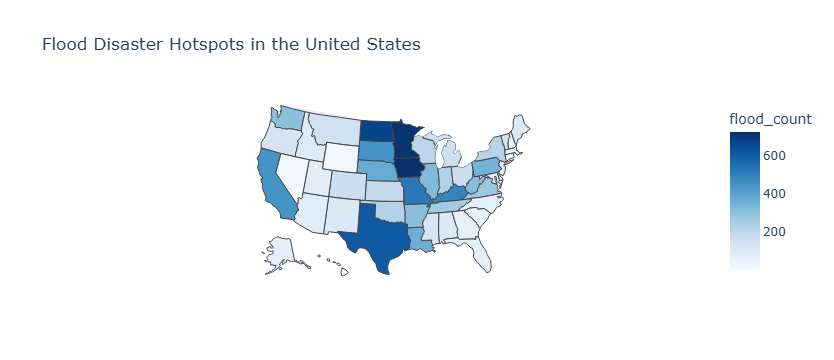

In [19]:
# Filter flood disasters
flood_data = data[data['incidentType'] == 'Flood']

# Count floods per state
flood_counts = flood_data['state'].value_counts().reset_index()
flood_counts.columns = ['state','flood_count']

# Create map
fig = px.choropleth(
    flood_counts,
    locations='state',
    locationmode="USA-states",
    color='flood_count',
    scope="usa",
    color_continuous_scale="Blues",
    title="Flood Disaster Hotspots in the United States"
)

fig.show()

**Interpretation**

This visualization highlights the geographical concentration of flood disasters across the United States. States with darker blue shades represent areas where flooding events occur more frequently. Flood hotspots are commonly found in regions with heavy rainfall, river systems, and coastal exposure.